### Imports ###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.constants

### Plotting Power Entering Ground ###

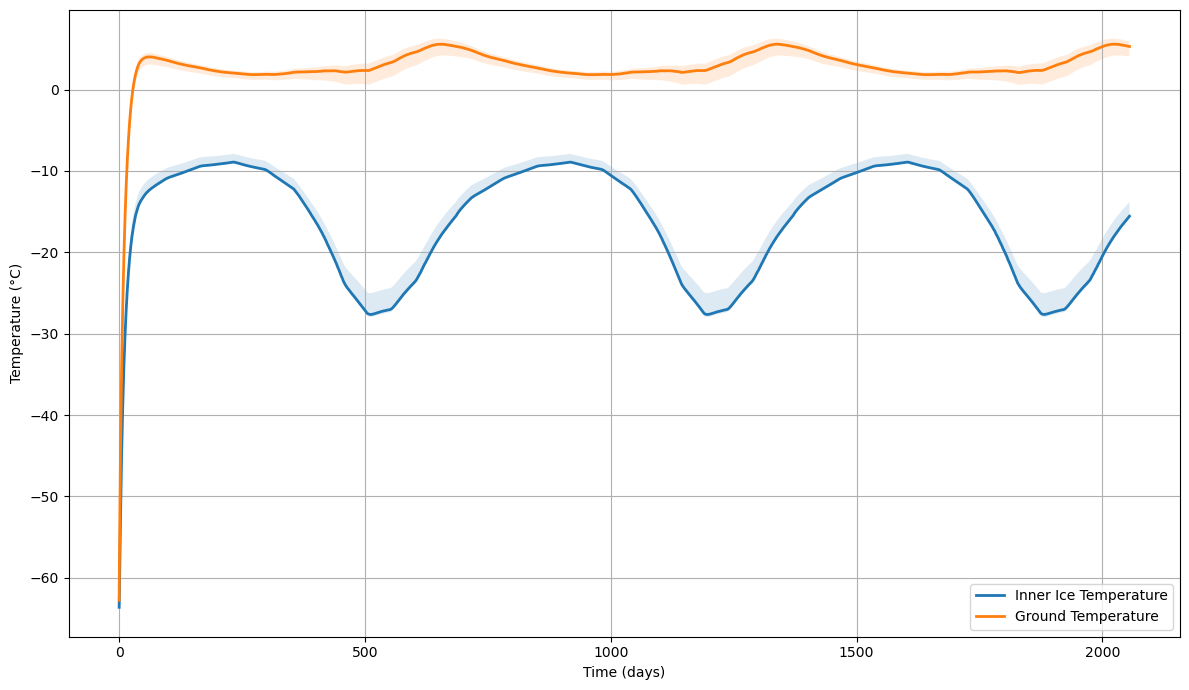

In [7]:
# Load data
file_path = "/Users/rafidquayum/Downloads/ice_habitat_powered_temps_seasonality_729.xlsx"

sheet1 = "temp_powered_inner_ice_729_278"
sheet2 = "temp_powered_ground_617_278"

inner_ice_df = pd.read_excel(file_path, sheet_name=sheet1)
ground_df = pd.read_excel(file_path, sheet_name=sheet2)

inner_ice_df['std'] = (inner_ice_df['max'] - inner_ice_df['min']) / 2
ground_df['std'] = (ground_df['max'] - ground_df['min']) / 2

plt.figure(figsize=(12, 7))

# Sheet 1
plt.plot(
    inner_ice_df['time']/86400, # seconds to days
    inner_ice_df['avg'],
    linewidth=2,
    label="Inner Ice Temperature"
)

plt.fill_between(
    inner_ice_df['time']/86400, # seconds to days,
    inner_ice_df['min'],
    inner_ice_df['max'],
    alpha=0.15
)

# Sheet 2
plt.plot(
    ground_df['time']/86400, # seconds to days,
    ground_df['avg'],
    linewidth=2,
    label="Ground Temperature"
)

plt.fill_between(
    ground_df['time']/86400, # seconds to days,
    ground_df['min'],
    ground_df['max'],
    alpha=0.15
)

plt.xlabel("Time (days)")
plt.ylabel("Temperature (°C)")
# plt.title("Powered Ice Habitat Temperatures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

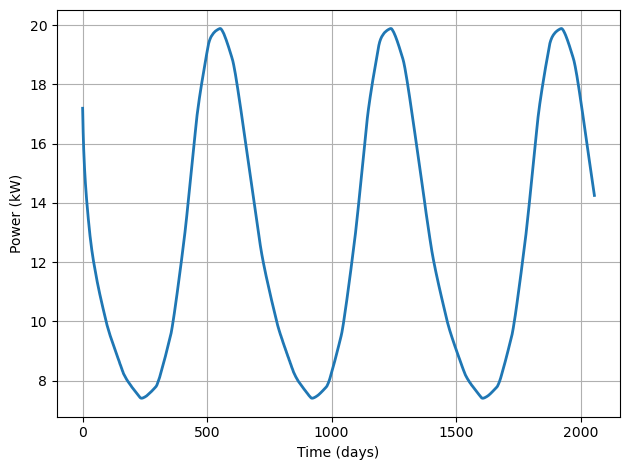

In [9]:
file_path_2 = "/Users/rafidquayum/Downloads/calculating_h_gen_surface_new_interpolated_data (2).xlsx"

sheet3 = "cal_h_gen_50_cm_red_pt2_t2_7_29"

power_df = pd.read_excel(file_path_2, sheet_name=sheet3)

plt.plot(
    power_df['time_278']/86400, # seconds to days
    power_df['power_added_W_278']/1000,
    linewidth=2,
    label="Power Added to Ground"
)

plt.ylabel("Power (kW)")
plt.xlabel("Time (days)")
# plt.title("Power Entering Ice Dome Ground")
# plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Ice Strain Plot ###

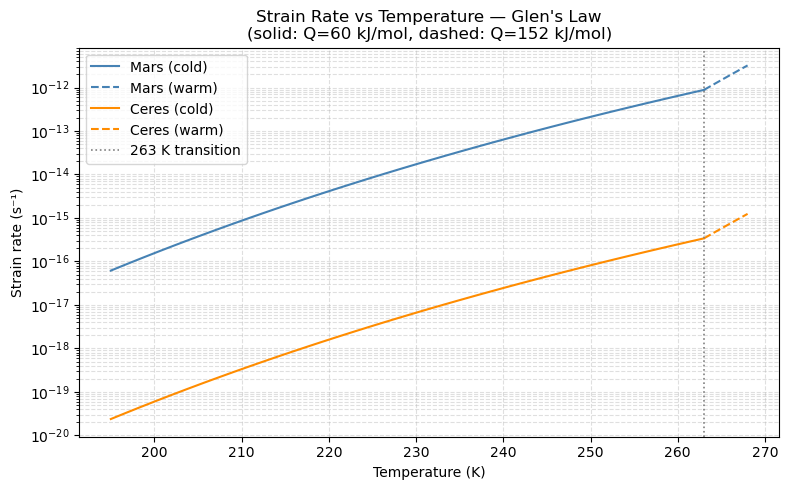

In [13]:
# Parameters
n = 3
rho_ice = 917       # kg/m^3
h = 4               # m
g_mars = 3.71       # m/s^2
g_ceres = 0.27      # m/s^2
stress_mars  = rho_ice * h * g_mars  
stress_ceres = rho_ice * h * g_ceres 

r = scipy.constants.R
a_o_guess = 3.5e-16

q_cold = 60000    # J/mol, T < 263 K
q_warm = 152000   # J/mol, T > 263 K

t_o = 195         # reference temperature (K)
T_transition = 263.0

# Temperature ranges based on Paterson 2006
t_cold = np.linspace(t_o, T_transition, 40)
t_warm = np.linspace(T_transition, 268, 15)

a_at_transition = 3.5e-25

a_warm_mars  = a_at_transition * np.exp(-q_warm / r * (1/t_warm - 1/T_transition))
a_warm_ceres = a_at_transition * np.exp(-q_warm / r * (1/t_warm - 1/T_transition))

a_cold_mars  = a_at_transition * np.exp(-q_cold / r * (1/t_cold - 1/T_transition))
a_cold_ceres = a_at_transition * np.exp(-q_cold / r * (1/t_cold - 1/T_transition))

# Strain rates
strain_cold_mars  = a_cold_mars  * stress_mars**n
strain_cold_ceres = a_cold_ceres * stress_ceres**n
strain_warm_mars  = a_warm_mars  * stress_mars**n
strain_warm_ceres = a_warm_ceres * stress_ceres**n

# Combined plot
fig, ax = plt.subplots(figsize=(8, 5))

# Mars
ax.plot(t_cold, strain_cold_mars,  color='steelblue',  label='Mars (cold)')
ax.plot(t_warm, strain_warm_mars,  color='steelblue',  linestyle='--', label='Mars (warm)')

# Ceres
ax.plot(t_cold, strain_cold_ceres, color='darkorange', label='Ceres (cold)')
ax.plot(t_warm, strain_warm_ceres, color='darkorange', linestyle='--', label='Ceres (warm)')

# Mark the transition
ax.axvline(T_transition, color='gray', linestyle=':', linewidth=1.2, label='263 K transition')

ax.set_yscale('log')
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Strain rate (s⁻¹)")
ax.set_title("Strain Rate vs Temperature — Glen's Law\n(solid: Q=60 kJ/mol, dashed: Q=152 kJ/mol)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Code to interpolate surface heating Q values to have same time stamps as inner ice temperature values (Ignore) ###

In [3]:
# Load datasets
heat_df = pd.read_csv("/Users/rafidquayum/Downloads/sky_temp_time_50cm_20red_surface_heating_t2.csv", header=None)
temp_df = pd.read_csv("/Users/rafidquayum/Downloads/sky_temp_time_50cm_20red_inner_ice_temp_t2.csv", header=None)

# Original heat-generation data
time_heat = heat_df.iloc[:, 0].values
heat_values = heat_df.iloc[:,1].values

# Convert data to float64
heat_df[0] = pd.to_numeric(heat_df[0], errors="coerce")
heat_df[1] = pd.to_numeric(heat_df[1], errors="coerce")

temp_df[0] = pd.to_numeric(temp_df[0], errors="coerce")
temp_df[1] = pd.to_numeric(temp_df[1], errors="coerce")

time_heat = heat_df[0].to_numpy(dtype=float)
heat_values = heat_df[1].to_numpy(dtype=float)
time_target = temp_df[0].to_numpy(dtype=float)

# Target timestamps (from temperature dataset)
time_target = temp_df.iloc[:,0].values

print(time_heat.dtype)
print(heat_values.dtype)
print(time_target.dtype)

# Interpolate
heat_interp = np.interp(time_target, time_heat, heat_values)

# Create new dataframe
result = pd.DataFrame({
    "time": time_target,
    "heat_gen_interp": heat_interp
})

result.to_csv("/Users/rafidquayum/Downloads/interpolated_surface_heating_data_50_cm_red_20_t4.csv", index=False)

print(result)

float64
float64
float64
             time  heat_gen_interp
0         10000.0        21.166171
1         15878.0        21.173324
2         21757.0        21.180479
3         39392.0        21.201942
4         57028.0        21.223406
...           ...              ...
1860  177150000.0        20.448882
1861  177250000.0        20.572647
1862  177350000.0        20.696765
1863  177450000.0        20.820471
1864  177550000.0        20.944000

[1865 rows x 2 columns]


### Archive (Ignore) ###

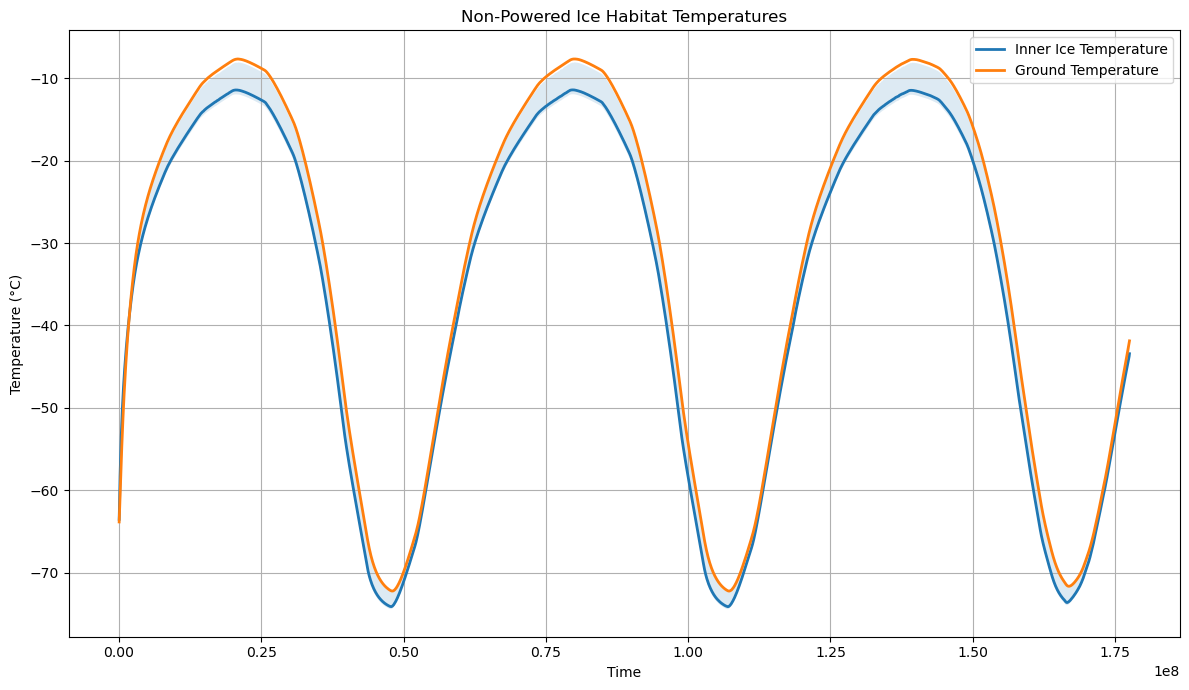

In [71]:
sheet4 = "temp_inner_ice"
sheet5 = "temp_ground_surf"

inner_ice_df = pd.read_excel(file_path, sheet_name=sheet4)
ground_df = pd.read_excel(file_path, sheet_name=sheet5)

inner_ice_df['std'] = (inner_ice_df['Maximum C'] - inner_ice_df['Minimum C']) / 2
ground_df['std'] = (ground_df['Maximum C'] - ground_df['Minimum C']) / 2

plt.figure(figsize=(12, 7))

# Sheet 1
plt.plot(
    inner_ice_df['Time'],
    inner_ice_df['Average C'],
    linewidth=2,
    label="Inner Ice Temperature"
)

plt.fill_between(
    inner_ice_df['Time'],
    inner_ice_df['Minimum C'],
    inner_ice_df['Maximum C'],
    alpha=0.15
)

# Sheet 2
plt.plot(
    ground_df['Time'],
    ground_df['Average C'],
    linewidth=2,
    label="Ground Temperature"
)

plt.fill_between(
    ground_df['Time'],
    ground_df['Minimum C'],
    ground_df['Maximum C'],
    alpha=0.1
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Non-Powered Ice Habitat Temperatures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()